# Task 2: Preprocessing for Europarl EN-PT

This notebook preprocesses the English-Portuguese Europarl corpus for later neural machine translation tasks.

Input files:

```python
DATA_DIR = Path("machine_learning/pt-en")
EN_PATH = DATA_DIR / "europarl-v7.pt-en.en"
PT_PATH = DATA_DIR / "europarl-v7.pt-en.pt"
```

Preprocessing steps:
- lowercase text
- remove empty lines and their aligned correspondences
- remove XML/meta-information lines starting with `<`
- remove duplicate sentence pairs
- optionally remove very long sentence pairs
- randomly sample 10% of the clean corpus for later model training


In [1]:
from pathlib import Path
import random
import pandas as pd
import matplotlib.pyplot as plt


# Your file path
DATA_DIR = Path("pt-en")

EN_PATH = DATA_DIR / "europarl-v7.pt-en.en"
PT_PATH = DATA_DIR / "europarl-v7.pt-en.pt"

OUTPUT_DIR = Path("outputs_task2")
OUTPUT_DIR.mkdir(exist_ok=True)

print("English file exists:", EN_PATH.exists(), EN_PATH)
print("Portuguese file exists:", PT_PATH.exists(), PT_PATH)

English file exists: True pt-en/europarl-v7.pt-en.en
Portuguese file exists: True pt-en/europarl-v7.pt-en.pt


## 1. Load the parallel corpus

The Europarl files may cause encoding issues on some systems. The function below first tries UTF-8 and falls back to Latin-1 if needed.

In [2]:
def read_lines(path: Path):
    """Read a text file and return lines without trailing newline characters."""
    try:
        with open(path, "r", encoding="utf-8") as f:
            return [line.rstrip("\n") for line in f]
    except UnicodeDecodeError:
        with open(path, "r", encoding="latin-1") as f:
            return [line.rstrip("\n") for line in f]

en_lines = read_lines(EN_PATH)
pt_lines = read_lines(PT_PATH)

print("Number of English lines:", len(en_lines))
print("Number of Portuguese lines:", len(pt_lines))
print("Aligned file-level line count:", len(en_lines) == len(pt_lines))

assert len(en_lines) == len(pt_lines), "English and Portuguese files have different numbers of lines."

Number of English lines: 1960407
Number of Portuguese lines: 1960407
Aligned file-level line count: True


## 2. Define preprocessing functions

In [3]:
def is_empty(line: str) -> bool:
    return line.strip() == ""


def is_xml_tag(line: str) -> bool:
    return line.strip().startswith("<")


def token_length(line: str) -> int:
    return len(line.strip().split())


def preprocess_pair(en: str, pt: str):
    """Lowercase and strip whitespace from an aligned sentence pair."""
    en = en.strip().lower()
    pt = pt.strip().lower()
    return en, pt

## 3. Preprocess the corpus

We keep sentence alignment by always filtering English and Portuguese lines together.

In [4]:
stats = []

raw_pairs = list(zip(en_lines, pt_lines))
stats.append(("Original parallel lines", len(raw_pairs)))

# Step 1: remove empty aligned pairs
non_empty_pairs = []
for en, pt in raw_pairs:
    if is_empty(en) or is_empty(pt):
        continue
    non_empty_pairs.append((en, pt))
stats.append(("After removing empty lines", len(non_empty_pairs)))

# Step 2: remove XML/meta-information lines
no_xml_pairs = []
for en, pt in non_empty_pairs:
    if is_xml_tag(en) or is_xml_tag(pt):
        continue
    no_xml_pairs.append((en, pt))
stats.append(("After removing XML lines", len(no_xml_pairs)))

# Step 3: lowercase and strip whitespace
lowercase_pairs = [preprocess_pair(en, pt) for en, pt in no_xml_pairs]
stats.append(("After lowercasing", len(lowercase_pairs)))

# Step 4: remove duplicate sentence pairs while preserving order
seen = set()
deduplicated_pairs = []
for pair in lowercase_pairs:
    if pair in seen:
        continue
    seen.add(pair)
    deduplicated_pairs.append(pair)
stats.append(("After removing duplicates", len(deduplicated_pairs)))

# Step 5: optionally remove very long sentence pairs
MAX_LEN = 80
filtered_pairs = []
for en, pt in deduplicated_pairs:
    if token_length(en) > MAX_LEN or token_length(pt) > MAX_LEN:
        continue
    filtered_pairs.append((en, pt))
stats.append((f"After removing pairs longer than {MAX_LEN} tokens", len(filtered_pairs)))

stats_df = pd.DataFrame(stats, columns=["Step", "Sentence pairs"])
display(stats_df)

stats_df.to_csv(OUTPUT_DIR / "preprocessing_statistics.csv", index=False)

,Step,Sentence pairs
0,Original parallel lines,1960407
1,After removing empty lines,1956459
2,After removing XML lines,1956459
3,After lowercasing,1956459
4,After removing duplicates,1913621
5,After removing pairs longer than 80 tokens,1897371


## 4. Visualize sentence-pair counts after each preprocessing step

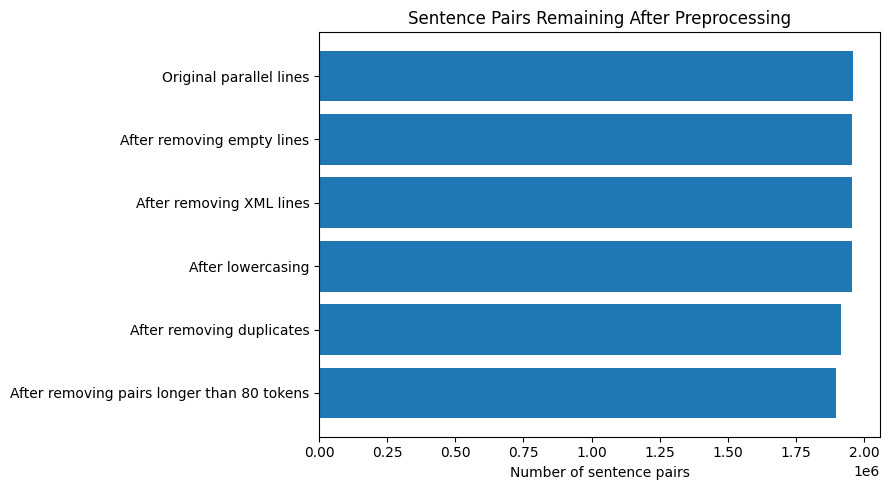

In [5]:
plt.figure(figsize=(9, 5))
plt.barh(stats_df["Step"][::-1], stats_df["Sentence pairs"][::-1])
plt.xlabel("Number of sentence pairs")
plt.title("Sentence Pairs Remaining After Preprocessing")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "preprocessing_sentence_counts.png", dpi=200)
plt.show()

## 5. Check sentence length after preprocessing

,count,mean,std,min,25%,50%,75%,90%,95%,99%,max
en_length,1897371.0,25.063648,13.696498,1.0,15.0,23.0,33.0,44.0,52.0,67.0,80.0
pt_length,1897371.0,25.394889,14.059422,1.0,15.0,23.0,33.0,45.0,53.0,68.0,80.0


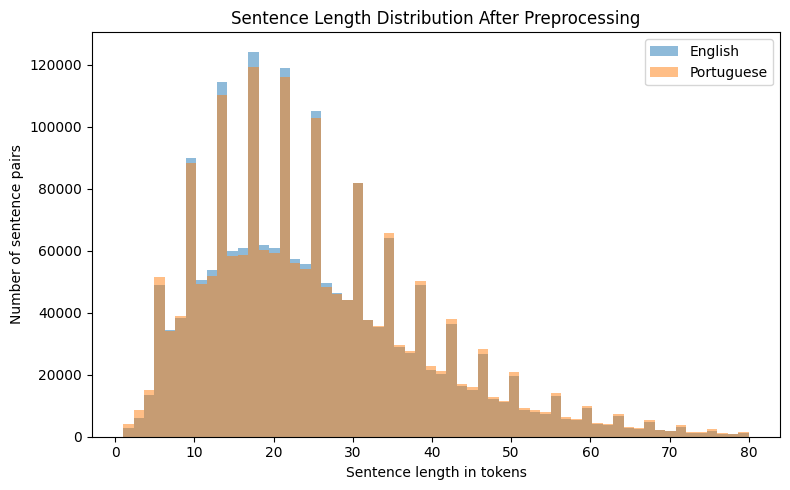

In [6]:
en_lengths = [token_length(en) for en, _ in filtered_pairs]
pt_lengths = [token_length(pt) for _, pt in filtered_pairs]

length_df = pd.DataFrame({
    "en_length": en_lengths,
    "pt_length": pt_lengths,
})

display(length_df.describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95, 0.99]).T)

plt.figure(figsize=(8, 5))
plt.hist(en_lengths, bins=60, alpha=0.5, label="English")
plt.hist(pt_lengths, bins=60, alpha=0.5, label="Portuguese")
plt.xlabel("Sentence length in tokens")
plt.ylabel("Number of sentence pairs")
plt.title("Sentence Length Distribution After Preprocessing")
plt.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "clean_sentence_length_distribution.png", dpi=200)
plt.show()

## 6. Save the full cleaned corpus

In [7]:
clean_en_path = OUTPUT_DIR / "clean_full.en"
clean_pt_path = OUTPUT_DIR / "clean_full.pt"

with open(clean_en_path, "w", encoding="utf-8") as f_en, open(clean_pt_path, "w", encoding="utf-8") as f_pt:
    for en, pt in filtered_pairs:
        f_en.write(en + "\n")
        f_pt.write(pt + "\n")

print("Saved full cleaned English corpus:", clean_en_path)
print("Saved full cleaned Portuguese corpus:", clean_pt_path)

Saved full cleaned English corpus: outputs_task2/clean_full.en
Saved full cleaned Portuguese corpus: outputs_task2/clean_full.pt


## 7. Randomly sample 10% for later model training

The assignment asks for a random 10% sample because the full dataset is too large. We use a fixed seed so that results are reproducible.

In [8]:
RANDOM_SEED = 42
SAMPLE_RATIO = 0.10

random.seed(RANDOM_SEED)
n_sample = int(SAMPLE_RATIO * len(filtered_pairs))
sample_indices = random.sample(range(len(filtered_pairs)), n_sample)
sample_pairs = [filtered_pairs[i] for i in sample_indices]

sample_en_path = OUTPUT_DIR / "clean_sample_10_percent.en"
sample_pt_path = OUTPUT_DIR / "clean_sample_10_percent.pt"

with open(sample_en_path, "w", encoding="utf-8") as f_en, open(sample_pt_path, "w", encoding="utf-8") as f_pt:
    for en, pt in sample_pairs:
        f_en.write(en + "\n")
        f_pt.write(pt + "\n")

print("Full cleaned sentence pairs:", len(filtered_pairs))
print("10% sampled sentence pairs:", len(sample_pairs))
print("Saved sampled English corpus:", sample_en_path)
print("Saved sampled Portuguese corpus:", sample_pt_path)

Full cleaned sentence pairs: 1897371
10% sampled sentence pairs: 189737
Saved sampled English corpus: outputs_task2/clean_sample_10_percent.en
Saved sampled Portuguese corpus: outputs_task2/clean_sample_10_percent.pt


## 8. Optional: create train/validation/test split for Task 3

Task 3 asks for a test set of 20%. The following split is optional here but useful later:

- 80% train
- 10% validation
- 10% test

This is based only on the 10% sampled corpus.

In [11]:
random.seed(RANDOM_SEED)
random.shuffle(sample_pairs)

n = len(sample_pairs)
n_train = int(0.80 * n)
n_val = int(0.10 * n)

train_pairs = sample_pairs[:n_train]
val_pairs = sample_pairs[n_train:n_train + n_val]
test_pairs = sample_pairs[n_train + n_val:]

print("Train pairs:", len(train_pairs))
print("Validation pairs:", len(val_pairs))
print("Test pairs:", len(test_pairs))

def save_pairs(pairs, en_path, pt_path):
    with open(en_path, "w", encoding="utf-8") as f_en, open(pt_path, "w", encoding="utf-8") as f_pt:
        for en, pt in pairs:
            f_en.write(en + "\n")
            f_pt.write(pt + "\n")

save_pairs(train_pairs, OUTPUT_DIR / "train.en", OUTPUT_DIR / "train.pt")
save_pairs(val_pairs, OUTPUT_DIR / "val.en", OUTPUT_DIR / "val.pt")
save_pairs(test_pairs, OUTPUT_DIR / "test.en", OUTPUT_DIR / "test.pt")

print("Saved train/val/test files in", OUTPUT_DIR)

Train pairs: 151789
Validation pairs: 18973
Test pairs: 18975
Saved train/val/test files in outputs_task2


## 9. Text for the report

You can adapt the following paragraph:

> We applied a conservative preprocessing pipeline to the English-Portuguese Europarl corpus. First, we removed empty lines and their aligned correspondences because they do not provide useful translation signals. Second, we removed XML and metadata lines starting with `<`, since they describe document structure rather than natural language sentences. Third, all text was lowercased to reduce vocabulary size and improve word coverage. We also removed duplicate sentence pairs to reduce redundancy. Finally, sentence pairs longer than 80 tokens were discarded to reduce training cost and avoid unstable sequence-to-sequence training on very long sequences. After preprocessing, we randomly sampled 10% of the cleaned corpus using a fixed random seed for reproducibility.
